In [55]:
import numpy as np
import matplotlib.pyplot as plt

# uses part 2 variables 
time = days
clean_flux = flux_median / linear_line
#makes the light cruve flatter so that the dip is easirer to measure

# this normalize so the normal brightness is about 1
clean_flux = clean_flux / np.median(clean_flux)

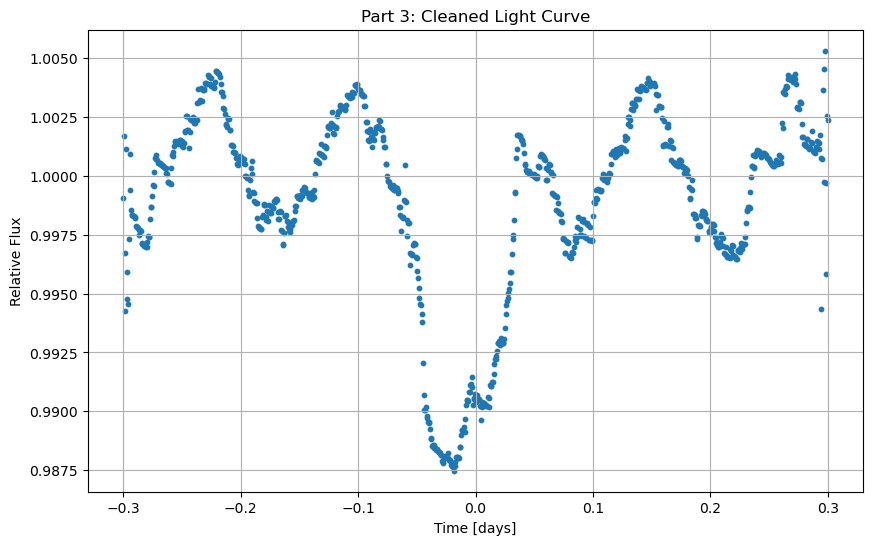

In [56]:
#ploting, labeling, and saving the cruve and then loading it to see
plt.figure(figsize=(10, 6))
plt.scatter(time, clean_flux, s=10)

plt.xlabel("Time [days]")
plt.ylabel("Relative Flux")
plt.title("Part 3: Cleaned Light Curve")
plt.grid(True)

plt.savefig("part3_cleaned_lightcurve.pdf")
plt.show()

In [57]:
#the idea that we are using here is that Transit depth = normal brightness - lowest brightness during transit
baseline_flux = np.median(clean_flux)
min_flux = np.min(clean_flux)

D = baseline_flux - min_flux # subtracts the two values we found above to ge thte transit depth

#this prints the values out
print("Baseline flux:", baseline_flux)
print("Minimum flux:", min_flux)
print("Transit depth D:", D)

Baseline flux: 1.0
Minimum flux: 0.9874762855729325
Transit depth D: 0.012523714427067456


In [58]:
threshold = baseline_flux - D/2
#makes a cut off line 

in_transit = clean_flux < threshold
#anything below that cut off line is now counted as being inside the transit


transit_start = time[in_transit][0]#start of transit, first point below the cut off
transit_end = time[in_transit][-1]# end of transit, last points below the cut off

#read the line to find out what it does
transit_length = transit_end - transit_start

#prints out the values
print("Transit start [days]:", transit_start)
print("Transit end [days]:", transit_end)
print("Transit length [days]:", transit_length)

Transit start [days]: -0.04474474474474477
Transit end [days]: 0.02492492492492493
Transit length [days]: 0.0696696696696697


In [59]:
R_star = 1  # solar radius which we assume to be 1

R_planet = R_star * np.sqrt(D)
#gets the radius of the planet by using the formula give and reagranging it.
print("Planet radius [solar radii]:", R_planet)

Planet radius [solar radii]: 0.11190940276432296


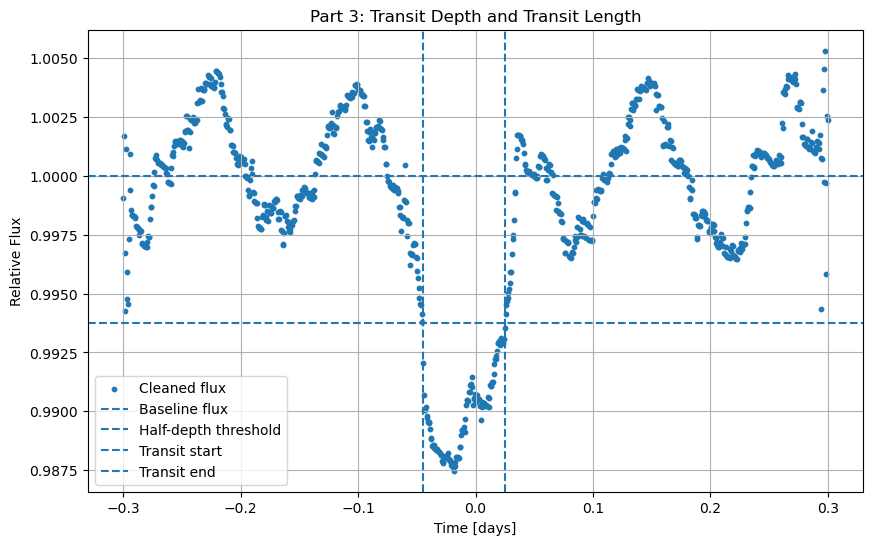

In [60]:
#making the final graph and printing it out
plt.figure(figsize=(10, 6))

plt.scatter(time, clean_flux, s=10, label="Cleaned flux")

plt.axhline(baseline_flux, linestyle="--", label="Baseline flux")
plt.axhline(threshold, linestyle="--", label="Half-depth threshold")
plt.axvline(transit_start, linestyle="--", label="Transit start")
plt.axvline(transit_end, linestyle="--", label="Transit end")

plt.xlabel("Time [days]")
plt.ylabel("Relative Flux")
plt.title("Part 3: Transit Depth and Transit Length")
plt.legend()
plt.grid(True)

plt.savefig("part3_transit_depth_and_length.pdf")
plt.show()

In [61]:
#just saving my final answer, print them out , and labeling them easier for later
transit_depth = D
transit_duration_days = transit_length
planet_radius_solar_radii = R_planet

D_fit = transit_depth
T_fit = transit_duration_days
N_in = np.sum(in_transit)
N_out = len(in_transit) - N_in


print("Final Part 3 Results")
print("Transit depth:", transit_depth)
print("Transit length:", transit_duration_days, "days")
print("Planet radius:", planet_radius_solar_radii, "solar radii")

Final Part 3 Results
Transit depth: 0.012523714427067456
Transit length: 0.0696696696696697 days
Planet radius: 0.11190940276432296 solar radii
